In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib

import torch
import torchvision
import torchvision.transforms.v2 as T
import torchvision.datasets as D

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from torchmetrics.classification import Accuracy
from torch.utils.tensorboard import SummaryWriter
from PIL import Image

In [8]:
root: pathlib.Path = pathlib.Path("./data/pizza_steak_sushi")

In [9]:
class ImageFolderDataset(Dataset):
    def __init__(self, annotation, transform = None):
        super(ImageFolderDataset, self).__init__()

        self.root = annotation
        self.annotation = list(annotation.glob("*/*.jpg"))
        # self.transform = transform
        self.classes, self.idx_classes = self._scanDir()
        self.transform = transform
        self.samples = [
            (image_path, self.idx_classes[image_path.parent.stem])
            for image_path in self.annotation
        ]

    def _scanDir(self):
        if not self.root.is_dir():
            raise FileNotFoundError(f"{self.root} isn't a directory! check again.")

        classes = [entry.name for entry in os.scandir(self.root)]
        idx_classes = {key: index for index, key in enumerate(classes)}

        return classes, idx_classes

    def __len__(self):
        return len(self.annotation)

    def __getitem__(self, index):
        image = Image.open(self.annotation[index])
        classname = self.annotation[index].parent.stem
        class_idx = self.idx_classes[classname]

        if self.transform:
            return self.transform(image), class_idx

        return image, class_idx

    def __repr__(self):
        return (f"CustomImageFolder \n"
        f"   Number of Datapoints: {len(self.annotation)} \n"
        f"   Root Location: {self.root} \n"
        f"   Transforms: {self.transform}")
        

In [10]:
train_path = root / "train"
test_path = root / "test"

In [11]:
preprocessing = T.Compose([
    T.Resize(size=(224, 224)),
    T.RandomHorizontalFlip(p = 0.5),
    T.TrivialAugmentWide(num_magnitude_bins = 31),
    T.ToImage(),
    T.ToDtype(dtype = torch.float32, scale = True),
    T.Normalize(mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225])
])

TestTransform = T.Compose([
    T.Resize(size=(224, 224)),
    T.ToImage(),
    T.ToDtype(dtype = torch.float32, scale = True),
    T.Normalize(mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225])
])

In [12]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [13]:
train_dataset = ImageFolderDataset(annotation = train_path, transform = preprocessing)
test_dataset = ImageFolderDataset(annotation = test_path, transform = TestTransform)

In [14]:
train_dataset, test_dataset

(CustomImageFolder 
    Number of Datapoints: 225 
    Root Location: data/pizza_steak_sushi/train 
    Transforms: Compose(
       Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
       RandomHorizontalFlip(p=0.5)
       TrivialAugmentWide(interpolation=InterpolationMode.NEAREST, num_magnitude_bins=31)
       ToImage()
       ToDtype(scale=True)
       Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
 ),
 CustomImageFolder 
    Number of Datapoints: 75 
    Root Location: data/pizza_steak_sushi/test 
    Transforms: Compose(
       Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
       ToImage()
       ToDtype(scale=True)
       Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
 ))

In [15]:
BATCH_SIZE = 16
NUM_WORKERS = 4
SHUFFLE = True

In [16]:
train_loader = DataLoader(train_dataset,
                         batch_size = BATCH_SIZE,
                         shuffle = SHUFFLE)

test_loader = DataLoader(test_dataset,
                        batch_size = BATCH_SIZE,
                        shuffle = False)

In [17]:
image, target = next(iter(train_loader))
# image[0]

In [18]:
def denormalizeImage(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 1, 3)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 1, 3)
    return img * std + mean

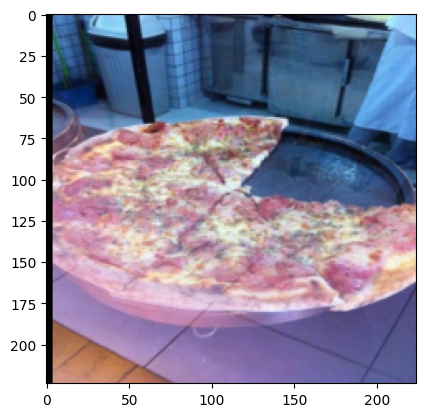

In [19]:
plt.imshow(denormalizeImage(image[0].permute(1, 2, 0)))

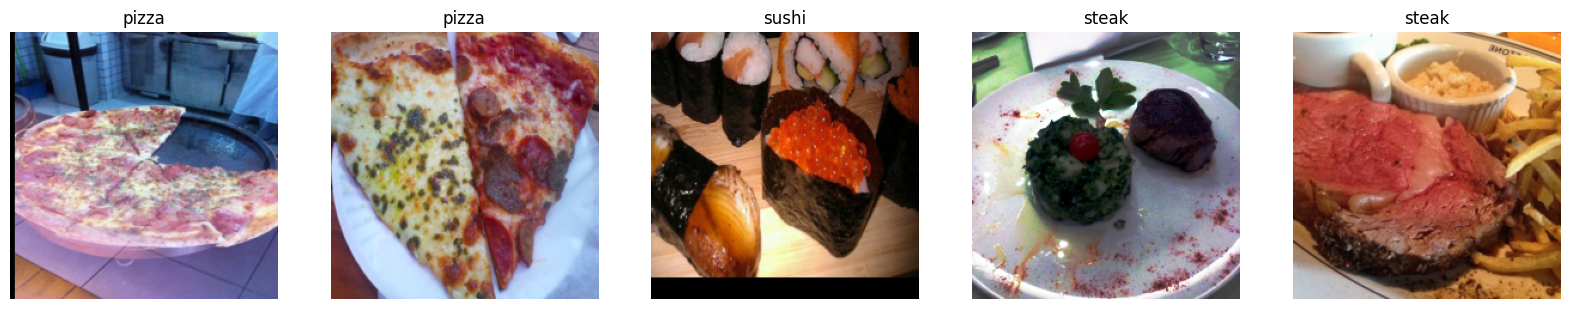

In [20]:
plt.figure(figsize = (20, 25))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(denormalizeImage(image[i].permute(1, 2, 0)))
    plt.title(train_dataset.classes[target[i]])
    plt.axis(False)
plt.show()

In [34]:
class TinyVGGModel(torch.nn.Module):
    def __init__(self, in_features: int = 3, hidden_units: int = 32,
                out_features: int = 3):
        self.in_features = in_features
        self.hidden_units = hidden_units
        self.out_features = out_features
        
        super(TinyVGGModel, self).__init__()

        self.block1 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.in_features,
                           out_channels = self.hidden_units,
                           kernel_size = (3, 3),
                           stride = 1,
                           padding = 0),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.hidden_units,
                           kernel_size = (3, 3),
                           stride = 1,
                           padding = 0),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = (2, 2), stride = 2)
        )

        self.block2 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.hidden_units,
                           kernel_size = (3, 3),
                           stride = 1,
                           padding = 0),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.hidden_units,
                           kernel_size = (3, 3),
                           stride = 1,
                           padding = 0),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = (2, 2), stride = 2)
        )

        self.classification = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = self.hidden_units * 53 * 53,
                            out_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classification(self.block2(self.block1(x)))
        

In [35]:
device = "mps" if torch.mps.is_available() else "cpu"

In [36]:
model = TinyVGGModel().to(device)

In [37]:
model

TinyVGGModel(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classification): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=89888, out_features=32, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)

In [38]:
with torch.inference_mode():
    y_logits = model(image.to(device))
    # y_pred = torch.argmax(torch.softmax(y_logits, dim = 1), dim = 1)
    y_pred = y_logits.argmax(dim = 1)

y_pred

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='mps:0')

In [39]:
def train_model(dataset, model, criterion, optimizer, accuracy_fn):
    running_loss = 0.0
    model.train()
    accuracy_fn.reset()
    
    for image, target in dataset:
        logits = model(image.to(device))
        loss = criterion(logits, target.to(device))
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        accuracy_fn.update(target.to(device), logits.argmax(dim = 1))

    avg_loss = running_loss / len(dataset)
    avg_acc = accuracy_fn.compute().item()

    return (avg_loss, avg_acc)

In [40]:
def test_model(dataset, model, criterion, optimizer, accuracy_fn):
    running_loss = 0.0
    model.eval()
    accuracy_fn.reset()

    with torch.inference_mode():   
        for image, target in dataset:
            logits = model(image.to(device))
            loss = criterion(logits, target.to(device))
            # optimizer.zero_grad()
    
            # loss.backward()
            # optimizer.step()
    
            running_loss += loss.item()
            accuracy_fn.update(target.to(device), logits.argmax(dim = 1))
    
        avg_loss = running_loss / len(dataset)
        avg_acc = accuracy_fn.compute().item()
    
        return (avg_loss, avg_acc)

In [41]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3)
accuracy_fn = Accuracy(task = "multiclass", num_classes = 3).to(device)
writer = SummaryWriter()

In [42]:
EPOCHS = 100
TOTAL_EPOCHS = []
TRAINING_LOSSES, TRAINING_ACCURACY = [], []
TESTING_LOSSES, TESTING_ACCURACY = [], []

In [45]:
for epoch in tqdm(range(EPOCHS)):
    train_loss, train_acc = train_model(dataset = train_loader,
                                       model = model,
                                       criterion = criterion,
                                       optimizer = optimizer,
                                       accuracy_fn = accuracy_fn)

    test_loss, test_acc = test_model(dataset = test_loader,
                                       model = model,
                                       criterion = criterion,
                                       optimizer = optimizer,
                                       accuracy_fn = accuracy_fn)

    TRAINING_LOSSES.append(train_loss), TRAINING_ACCURACY.append(train_acc)
    TESTING_LOSSES.append(test_loss), TESTING_ACCURACY.append(test_acc)
    TOTAL_EPOCHS.append(epoch)

    writer.add_scalars(main_tag = "Loss",
                     tag_scalar_dict = {
                         "train_loss": train_loss,
                         "test_loss": test_loss
                     }, global_step = epoch)

    writer.add_scalars(main_tag = "Accuracy",
                     tag_scalar_dict = {
                         "train_acc": train_acc,
                         "test_acc": test_acc
                     }, global_step = epoch)

    writer.add_graph(model = model, input_to_model = 
                    torch.randn([16, 3, 224, 224]).to(device))

    if epoch % (EPOCHS * 0.2) == 0:
        print(f"Training Losses: {train_loss} | Training Accuracy: {train_acc}")
        print(f"Testing Losses: {test_loss} | Testing Accuracy: {test_acc} \n")

writer.close()

  1%|▍                                          | 1/100 [00:01<02:36,  1.58s/it]

Training Losses: 1.0985190550486246 | Training Accuracy: 0.3333333432674408
Testing Losses: 1.1118840456008912 | Testing Accuracy: 0.25333333015441895 



 21%|████████▊                                 | 21/100 [00:30<01:55,  1.46s/it]

Training Losses: 0.8739059448242188 | Training Accuracy: 0.5733333230018616
Testing Losses: 1.33079537153244 | Testing Accuracy: 0.4266666769981384 



 41%|█████████████████▏                        | 41/100 [00:59<01:25,  1.46s/it]

...

 61%|█████████████████████████▌                | 61/100 [01:29<00:57,  1.48s/it]

Training Losses: 0.7902266184488932 | Training Accuracy: 0.6622222065925598
Testing Losses: 1.0061224460601808 | Testing Accuracy: 0.5066666603088379 



 81%|██████████████████████████████████        | 81/100 [01:58<00:27,  1.46s/it]

Training Losses: 0.4048636053999265 | Training Accuracy: 0.8622221946716309
Testing Losses: 1.3548341274261475 | Testing Accuracy: 0.54666668176651 



100%|█████████████████████████████████████████| 100/100 [02:26<00:00,  1.46s/it]


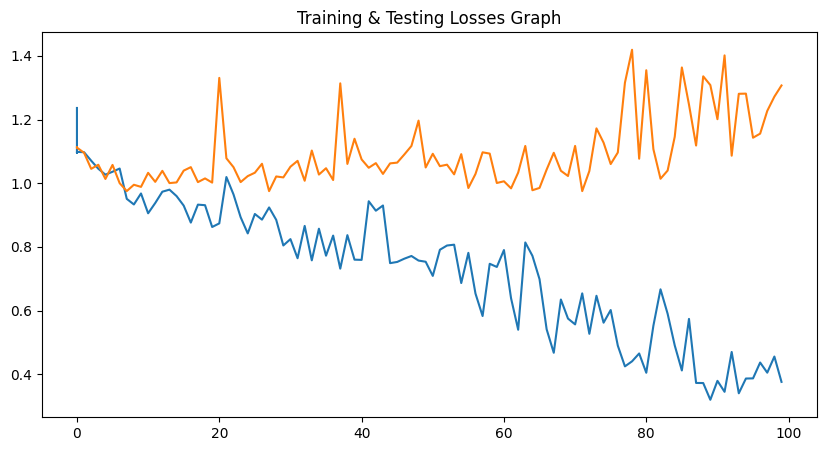

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(TOTAL_EPOCHS, TRAINING_LOSSES)
plt.plot(TOTAL_EPOCHS, TESTING_LOSSES)
plt.title("Training & Testing Losses Graph")
plt.show()

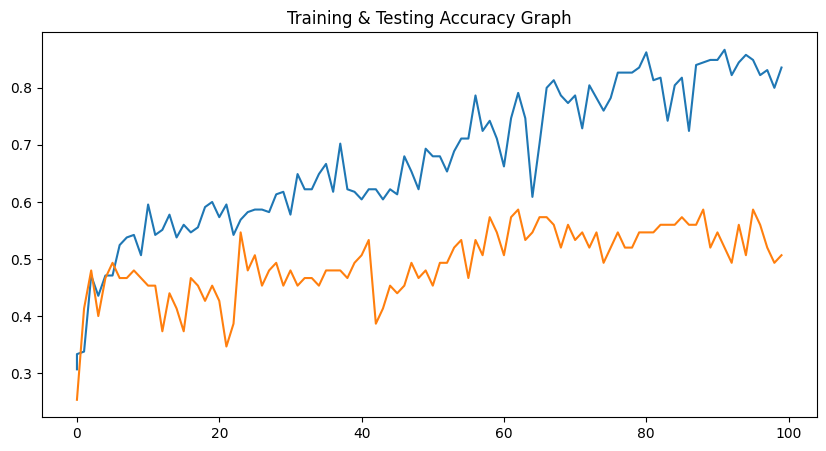

In [51]:
plt.figure(figsize=(10, 5))
plt.plot(TOTAL_EPOCHS, TRAINING_ACCURACY)
plt.plot(TOTAL_EPOCHS, TESTING_ACCURACY)
plt.title("Training & Testing Accuracy Graph")
plt.show()

In [52]:
pizza_image = pathlib.Path("../datasets/pizza_image.jpg")
sushi_image = pathlib.Path("../datasets/shushi.jpg")

In [53]:
_custom_pizzaImg = Image.open(pizza_image).convert("RGB")
_custom_shushiImg = Image.open(sushi_image).convert("RGB")

In [54]:
_pizza_transformed = TestTransform(_custom_pizzaImg)
_pizza_transformed.shape

_shushi_transformed = TestTransform(_custom_shushiImg)

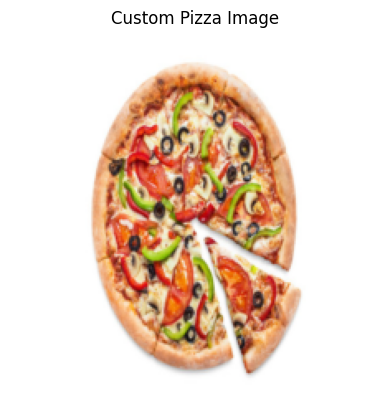

In [55]:
plt.imshow(denormalizeImage(_pizza_transformed.permute(1, 2, 0)))
plt.title("Custom Pizza Image")
plt.axis("off")
plt.show()

In [56]:
with torch.inference_mode():
    
    logits = model(_pizza_transformed.to(device).unsqueeze(0))
    pred = logits.argmax(dim = 1)

train_dataset.classes[pred]

'sushi'

In [57]:
with torch.inference_mode():
    
    logits = model(_shushi_transformed.to(device).unsqueeze(0))
    pred = logits.argmax(dim = 1)

train_dataset.classes[pred]

'pizza'

In [49]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [60]:
from torchinfo import summary

summary(model, input_size = (16, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGGModel                             [16, 3]                   --
├─Sequential: 1-1                        [16, 32, 110, 110]        --
│    └─Conv2d: 2-1                       [16, 32, 222, 222]        896
│    └─ReLU: 2-2                         [16, 32, 222, 222]        --
│    └─Conv2d: 2-3                       [16, 32, 220, 220]        9,248
│    └─ReLU: 2-4                         [16, 32, 220, 220]        --
│    └─MaxPool2d: 2-5                    [16, 32, 110, 110]        --
├─Sequential: 1-2                        [16, 32, 53, 53]          --
│    └─Conv2d: 2-6                       [16, 32, 108, 108]        9,248
│    └─ReLU: 2-7                         [16, 32, 108, 108]        --
│    └─Conv2d: 2-8                       [16, 32, 106, 106]        9,248
│    └─ReLU: 2-9                         [16, 32, 106, 106]        --
│    └─MaxPool2d: 2-10                   [16, 32, 53, 53]          --
├─Seq

In [64]:
food_path = pathlib.Path("../datasets/food-101/")

In [63]:
print(list(entry.name for entry in os.scandir(food_path)))

['foie_gras', 'club_sandwich', 'cheese_plate', 'cup_cakes', 'garlic_bread', 'gnocchi', 'ice_cream', 'samosa', 'donuts', 'tuna_tartare', 'filet_mignon', '.DS_Store', 'seaweed_salad', 'french_toast', 'chicken_curry', 'shrimp_and_grits', 'steak', 'cheesecake', 'red_velvet_cake', 'waffles', 'churros', 'gyoza', 'lobster_roll_sandwich', 'huevos_rancheros', 'breakfast_burrito', 'grilled_cheese_sandwich', 'spaghetti_bolognese', 'falafel', 'poutine', 'greek_salad', 'beef_tartare', 'fried_calamari', 'guacamole', 'ravioli', 'lobster_bisque', 'beet_salad', 'risotto', 'crab_cakes', 'strawberry_shortcake', 'edamame', 'ceviche', 'hot_and_sour_soup', 'spring_rolls', 'sashimi', 'paella', 'clam_chowder', 'miso_soup', 'escargots', 'hot_dog', 'pulled_pork_sandwich', 'bruschetta', 'panna_cotta', 'fish_and_chips', 'pad_thai', 'tiramisu', 'takoyaki', 'macarons', 'apple_pie', 'cannoli', 'scallops', 'frozen_yogurt', 'chicken_quesadilla', 'mussels', 'beef_carpaccio', 'eggs_benedict', 'spaghetti_carbonara', 'ome

In [65]:
meta_train = food_path / "meta" / "train.txt"

In [75]:
train_img_path = []

with open(meta_train, "r") as f:
    for line in f:
        train_img_path.append(line.strip())

# train_img_path[1]

In [76]:
train_img_path[10000]

'caprese_salad/2298463'

In [ ]:
int(0.8 * 5000)